## **Setup Dependencies**

In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np
import statistics as st
import shutil
import math
import librosa
import librosa.display
import subprocess

## **Project Setup**

In [3]:
# Project Dataset Paths (Note: the naming convention
# is D prefix concatenate to a dataset type (either raw,
# or process) and the first character of folder, Ex: DA 
# because D stands for dataset and A is the starting letter of the folder )
DPATH: str = "../datasets" 
DRPATH: str = os.path.join(DPATH, "raw")
DPPATH: str = os.path.join(DPATH, "process")
DIPATH: str = os.path.join(DPATH, "interim")
DIAPATH: str = os.path.join(DIPATH, "anuran")
DRAPATH: str = os.path.join(DRPATH, "anuran")
DPFPATH: str = os.path.join(DPPATH, "frog")
DPBPATH: str = os.path.join(DPPATH, "bat")
DPPPATH: str = os.path.join(DPPATH, "pig")
AUDFORMAT: tuple = (".mp3", ".m4a", ".wav")

# Folder name of current dataset
ANPATH: str = "anuran"

SR: int = 44100
FORMAT: str = ".wav"

In [23]:
# Parameter tuning
plt.rcParams.update({"font.size": 8})

## **Raw Data Analysis**

---
The following our the datum that you need to know about the
dataset. The purpose is to educate the developers on what
they should know about the data.

**anrunan** - This is a frog dataset.

In [4]:
# Here are additional information for each dataset from raw folder
print(f"Anuran--> Number of contents: {len(os.listdir(DRAPATH))}")
print(f"Anuran--> Number of files: {len(list(filter(lambda x: x.endswith(AUDFORMAT), os.listdir(DRAPATH))))}")

Anuran--> Number of contents: 30
Anuran--> Number of files: 30


In [5]:
# Make sure that file which you load is a wav file
# in that everything that is currently processing
# that is not finished would be automatically
# reference to the interim
def select_dataset(folder: str | list, size: str) -> None: 
    if type(folder) == list:
        os.makedirs(list(map(lambda x: os.path.join(DIPATH, x), folder)), exist_ok=True)
        for fold in folder:
            ids: int = 0
            for file in os.listdir(os.path.join(DRPATH, fold)):
                if file.endswith(AUDFORMAT) and not file.endswith(FORMAT):
                    subprocess.call(["ffmpeg", "-i", 
                                     f"{os.path.join(DRPATH, fold, file)}", 
                                     os.path.join(DIPATH, fold, f"{fold}-{ids}{wav}")])
                    ids+=1
                if ids == size:
                    break
    else:
        os.makedirs(os.path.join(DIPATH, folder), exist_ok=True)
        ids: int = 0
        for file in os.listdir(os.path.join(DRPATH, folder)):
            if file.endswith(AUDFORMAT) and not file.endswith(FORMAT):
                # To make sure that the files does duplicate based on
                # pre existing files on interim
                if ids < len(os.listdir(os.path.join(DIPATH, folder))):
                    subprocess.call(["ffmpeg", "-i", 
                                     f"{os.path.join(DRPATH, folder, file)}", 
                                     os.path.join(DIPATH, folder, f"{folder}-{ids}{FORMAT}")],
                                   stderr=subprocess.DEVNULL, stdout=subprocess.DEVNULL)
                else:
                    print(f"ERROR: already existed")
                ids+=1
            if ids == size:
                break

In [8]:
# Dataset loader or handler to make it easier to load the collection of audio files
def get_dataset(path: str) -> list:
    aud: list = []
    for file in os.listdir(path):
        print(os.path.join(path, file))
        if file.endswith(FORMAT):
            aud.append(librosa.load(os.path.join(path, file), sr=SR, mono=True))
    return aud

Anuran is a small set of m4a audio files. Analysis is a lot easier to do in this case and let's proceed to define
the general gist of analysis.

In [9]:
select_dataset(ANPATH, len(os.listdir(DRAPATH)))
an_aud: list = get_dataset(DIAPATH)

../datasets/interim/anuran/anuran-26.wav
../datasets/interim/anuran/anuran-10.wav
../datasets/interim/anuran/anuran-20.wav
../datasets/interim/anuran/anuran-0.wav
../datasets/interim/anuran/anuran-25.wav
../datasets/interim/anuran/anuran-21.wav
../datasets/interim/anuran/anuran-4.wav
../datasets/interim/anuran/anuran-22.wav
../datasets/interim/anuran/anuran-5.wav
../datasets/interim/anuran/anuran-8.wav
../datasets/interim/anuran/anuran-24.wav
../datasets/interim/anuran/anuran-14.wav
../datasets/interim/anuran/anuran-11.wav
../datasets/interim/anuran/anuran-17.wav
../datasets/interim/anuran/anuran-12.wav
../datasets/interim/anuran/anuran-6.wav
../datasets/interim/anuran/anuran-1.wav
../datasets/interim/anuran/anuran-18.wav
../datasets/interim/anuran/anuran-7.wav
../datasets/interim/anuran/anuran-27.wav
../datasets/interim/anuran/anuran-13.wav
../datasets/interim/anuran/anuran-9.wav
../datasets/interim/anuran/anuran-3.wav
../datasets/interim/anuran/anuran-29.wav
../datasets/interim/anura

In [10]:
# Statistical Analysis
print(f"Anuran: Mean {st.mean(map(lambda audio: librosa.get_duration(y=audio[0], sr=audio[1]), an_aud))}")
print(f"Anuran: Median {st.median(map(lambda audio: librosa.get_duration(y=audio[0], sr=audio[1]), an_aud))}")
print(f"Anuran: Variance {st.variance(map(lambda audio: librosa.get_duration(y=audio[0], sr=audio[1]), an_aud))}")
print(f"Anuran: Standard Deviation {st.stdev(map(lambda audio: librosa.get_duration(y=audio[0], sr=audio[1]), an_aud))}")
print(f"Anuran: Range {np.ptp(list(map(lambda audio: librosa.get_duration(y=audio[0], sr=audio[1]), an_aud)))}")

Anuran: Mean 2.3296092214663644
Anuran: Median 2.368004535147392
Anuran: Variance 0.15619543984115222
Anuran: Standard Deviation 0.3952156877467698
Anuran: Range 1.6639909297052156


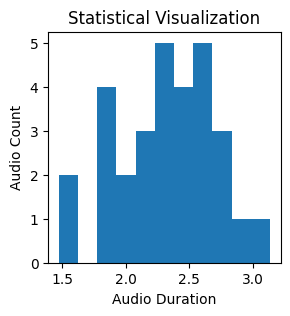

<Figure size 500x500 with 0 Axes>

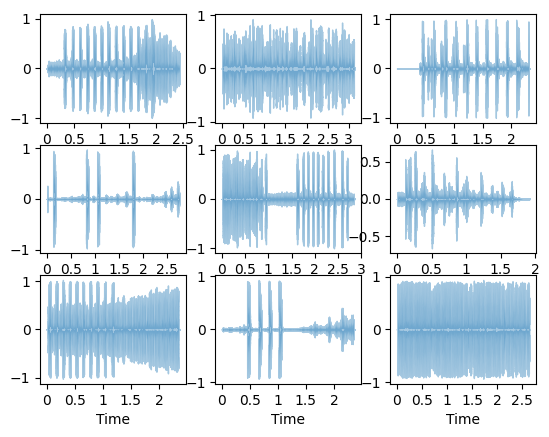

In [11]:
# Visualization of Analysis
plt.figure(figsize=(3,3))

# Duration
plt.hist(list(map(lambda audio: librosa.get_duration(y=audio[0], sr=audio[1]), an_aud)), bins=int(0.3952156877467698*30))
plt.xlabel("Audio Duration")
plt.ylabel("Audio Count")
plt.title("Statistical Visualization")
plt.show()

# A samples of the audio files
plt.figure(figsize=(5,5))
plt.tight_layout(pad=2.5)
plt.subplots_adjust(wspace=0.7, hspace=0.9)
factor: int = 3
fig, ax = plt.subplots(factor, factor)
for i in range(factor ** 2):
    librosa.display.waveshow(an_aud[i][0], sr=an_aud[i][1], ax=ax[i%factor][i//factor], alpha=0.4)

## Interim Data Analysis
---
These are the different phases taken or the final product of the audio which will be first taken as the final checkpoint. It will be logical if this notebook will be liberted to transfer the final product to process folder to ready the training.

In [14]:
# Anuran progress check
last_checkpoint_anuran: str = list(filter(lambda x: x.startswith("phase_"), os.listdir(DIAPATH)))[-1]
an_aud: list = get_dataset(os.path.join(DIAPATH, last_checkpoint_anuran))

# Statistical Analysis
print(f"Anuran: Mean {st.mean(map(lambda audio: librosa.get_duration(y=audio[0], sr=audio[1]), an_aud))}")
print(f"Anuran: Median {st.median(map(lambda audio: librosa.get_duration(y=audio[0], sr=audio[1]), an_aud))}")
print(f"Anuran: Variance {st.variance(map(lambda audio: librosa.get_duration(y=audio[0], sr=audio[1]), an_aud))}")
print(f"Anuran: Standard Deviation {st.stdev(map(lambda audio: librosa.get_duration(y=audio[0], sr=audio[1]), an_aud))}")
print(f"Anuran: Range {np.ptp(list(map(lambda audio: librosa.get_duration(y=audio[0], sr=audio[1]), an_aud)))}")

../datasets/interim/anuran/phase_1/anuran-26.wav
../datasets/interim/anuran/phase_1/anuran-10.wav
../datasets/interim/anuran/phase_1/anuran-20.wav
../datasets/interim/anuran/phase_1/anuran-0.wav
../datasets/interim/anuran/phase_1/anuran-25.wav
../datasets/interim/anuran/phase_1/anuran-21.wav
../datasets/interim/anuran/phase_1/anuran-4.wav
../datasets/interim/anuran/phase_1/anuran-22.wav
../datasets/interim/anuran/phase_1/anuran-5.wav
../datasets/interim/anuran/phase_1/anuran-8.wav
../datasets/interim/anuran/phase_1/anuran-24.wav
../datasets/interim/anuran/phase_1/anuran-14.wav
../datasets/interim/anuran/phase_1/anuran-11.wav
../datasets/interim/anuran/phase_1/anuran-17.wav
../datasets/interim/anuran/phase_1/anuran-12.wav
../datasets/interim/anuran/phase_1/anuran-6.wav
../datasets/interim/anuran/phase_1/anuran-1.wav
../datasets/interim/anuran/phase_1/anuran-18.wav
../datasets/interim/anuran/phase_1/anuran-7.wav
../datasets/interim/anuran/phase_1/anuran-27.wav
../datasets/interim/anuran/

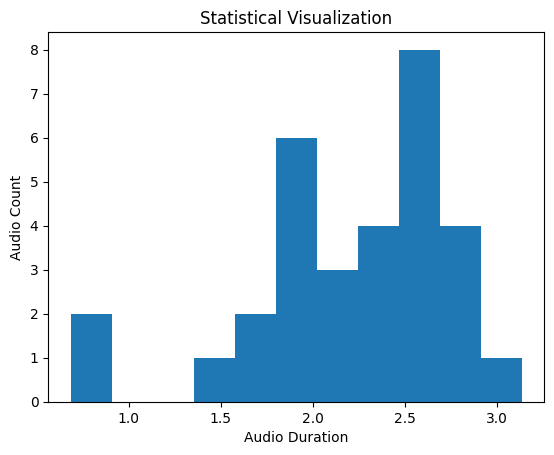

In [16]:
# We can re-evaluate the changes in durations
# Visualization of Analysis

# Duration
plt.hist(list(map(lambda audio: librosa.get_duration(y=audio[0], sr=audio[1]), an_aud)), bins=int(0.3952156877467698*30))
plt.xlabel("Audio Duration")
plt.ylabel("Audio Count")
plt.title("Statistical Visualization")
plt.show()

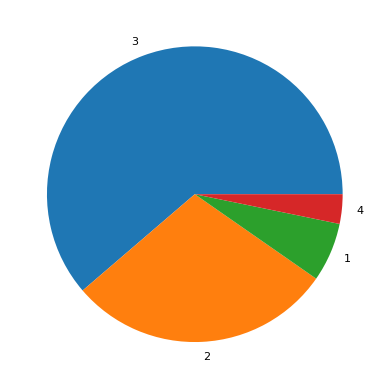

In [28]:
# Order each audio file by duration
order_by_dur: dict = {}
for audio in an_aud:
    dur: int = math.ceil(librosa.get_duration(y=audio[0], sr=audio[1]))
    if not order_by_dur.get(dur):
        order_by_dur[dur] = []
    order_by_dur[dur].append(audio)

# Generate a pie chart to understand the magnitude of
# durations changes. This is to note that the size of
# anuran is small which works in this case.
counts: list = []
for key in order_by_dur.keys():
    counts.append(len(order_by_dur[key]))
value = np.array(counts)
label = list(order_by_dur.keys())
plt.pie(value, labels=label)
plt.show()

## **Process Data Analysis**
---
So far, this is the only readily avaliable process set...
- Anuran

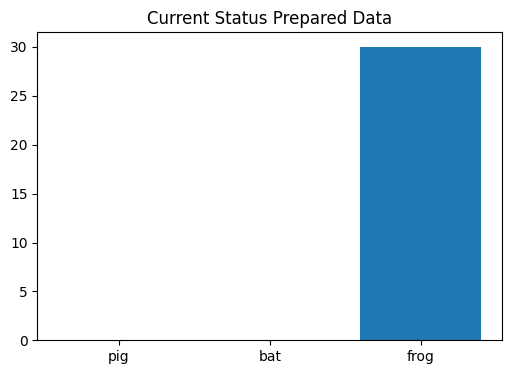

In [6]:
# Let's have a current update of the scale
# of the dataset
data_label: list = ["pig", "bat", "frog"]
data_count: list = [len(os.listdir(DPPPATH)), len(os.listdir(DPBPATH)), len(os.listdir(DPFPATH))]

plt.figure(figsize=(6, 4))
plt.bar(data_label, data_count)
plt.title("Current Status Prepared Data")
plt.show()